In [1]:
import os
import json
import math
import copy
import csv
import time

import numpy as np
import nibabel as nib

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset

In [2]:
with open(
    "data_split.json",
    "r"
) as f:
    split_data = json.load(f)


train_subjects = split_data["train"]
val_subjects = split_data["validation"]
test_subjects = split_data["test"]


print("Train:", len(train_subjects))
print("Validation:", len(val_subjects))
print("Test:", len(test_subjects))


heldout_subjects = sorted(
    list(val_subjects)
    + list(test_subjects)
)


if len(heldout_subjects) < 200:
    raise RuntimeError(
        "Fewer than 200 held-out subjects are available."
    )


overlap = (
    set(train_subjects)
    .intersection(
        set(heldout_subjects)
    )
)

if overlap:
    raise RuntimeError(
        "Training/held-out subject overlap detected."
    )


print(
    "Total held-out subjects:",
    len(heldout_subjects)
)

Train: 1000
Validation: 125
Test: 126


In [3]:
DATA_DIR = (
    "Data/"
    "ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData"
)


if not os.path.isdir(DATA_DIR):
    raise FileNotFoundError(
        f"BraTS data directory not found: {DATA_DIR}"
    )


print(
    "BraTS data directory:",
    DATA_DIR
)

In [4]:
def preprocess_t2f(image):

    if image.shape != (240, 240, 155):
        raise ValueError(
            f"Unexpected image shape: {image.shape}"
        )

    # Crop to 208 x 224 x 155
    image = image[16:224, 8:232, :]

    # Pad depth to 160
    image = np.pad(
        image,
        ((0, 0), (0, 0), (2, 3)),
        mode="constant",
        constant_values=0
    )

    # True original brain foreground
    brain_mask = image > 0

    if not np.any(brain_mask):
        raise ValueError(
            "No foreground voxels found"
        )

    upper = np.percentile(
        image[brain_mask],
        99.9
    )

    image = np.clip(
        image,
        0,
        upper
    )

    # [0,1]
    image = image / upper

    # [-1,1]
    image = (
        image * 2.0
        - 1.0
    )

    # Explicitly enforce air background
    image[~brain_mask] = -1.0

    return (
        image.astype(np.float32),
        brain_mask.astype(np.bool_)
    )

In [5]:
def preprocess_mask(mask):

    if mask.shape != (240, 240, 155):
        raise ValueError(
            f"Unexpected mask shape: {mask.shape}"
        )

    mask = mask[16:224, 8:232, :]

    mask = np.pad(
        mask,
        ((0, 0), (0, 0), (2, 3)),
        mode="constant",
        constant_values=0
    )

    return mask.astype(
        np.int64
    )

In [6]:
def calculate_tumour_entropy(
    image,
    mask,
    num_bins=256
):

    tumour_region = (
        mask > 0
    )

    if not np.any(
        tumour_region
    ):
        raise ValueError(
            "No tumour voxels found"
        )

    # image is stored in [-1,1]
    # Convert back to [0,1]
    image_01 = (
        image + 1.0
    ) / 2.0

    image_01 = np.clip(
        image_01,
        0.0,
        1.0
    )

    tumour_values = (
        image_01[
            tumour_region
        ]
    )

    hist, _ = np.histogram(
        tumour_values,
        bins=num_bins,
        range=(0.0, 1.0),
        density=False
    )

    probabilities = (
        hist.astype(
            np.float64
        )
    )

    probabilities = (
        probabilities
        / probabilities.sum()
    )

    probabilities = (
        probabilities[
            probabilities > 0
        ]
    )

    entropy = -np.sum(
        probabilities
        * np.log2(
            probabilities
        )
    )

    return np.float32(
        entropy
    )

In [7]:
class BraTSDataset(Dataset):

    def __init__(
        self,
        subjects,
        data_dir
    ):
        self.subjects = subjects
        self.data_dir = data_dir

    def __len__(self):
        return len(
            self.subjects
        )

    def __getitem__(
        self,
        idx
    ):

        subject = (
            self.subjects[idx]
        )

        subject_path = os.path.join(
            self.data_dir,
            subject
        )

        files = os.listdir(
            subject_path
        )

        t2f_files = [
            f for f in files
            if "t2f" in f.lower()
        ]

        seg_files = [
            f for f in files
            if "seg" in f.lower()
        ]

        if len(t2f_files) == 0:
            raise FileNotFoundError(
                f"No T2f file found for {subject}"
            )

        if len(seg_files) == 0:
            raise FileNotFoundError(
                f"No segmentation found for {subject}"
            )

        image = nib.load(
            os.path.join(
                subject_path,
                t2f_files[0]
            )
        ).get_fdata()

        mask = nib.load(
            os.path.join(
                subject_path,
                seg_files[0]
            )
        ).get_fdata()

        image, brain_mask = (
            preprocess_t2f(
                image
            )
        )

        mask = preprocess_mask(
            mask
        )

        entropy = (
            calculate_tumour_entropy(
                image,
                mask
            )
        )

        image = (
            torch.from_numpy(
                image
            )
            .float()
            .unsqueeze(0)
        )

        brain_mask = (
            torch.from_numpy(
                brain_mask
            )
            .bool()
            .unsqueeze(0)
        )

        mask = (
            torch.from_numpy(
                mask
            )
            .long()
            .unsqueeze(0)
        )

        entropy = torch.tensor(
            entropy,
            dtype=torch.float32
        )

        return {
            "image": image,
            "brain_mask": brain_mask,
            "mask": mask,
            "heterogeneity": entropy,
            "subject": subject
        }

In [8]:
train_dataset = BraTSDataset(
    subjects=train_subjects,
    data_dir=train_data
)

print("Dataset size:", len(train_dataset))

Dataset size: 1000


In [9]:
train_loader = DataLoader(
    train_dataset,
    batch_size=1,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

print(
    "Training batches:",
    len(train_loader)
)

Training batches: 1000


In [10]:
sample = train_dataset[0]

print(
    "Subject:",
    sample["subject"]
)

print(
    "Image shape:",
    sample["image"].shape
)

print(
    "Brain mask shape:",
    sample["brain_mask"].shape
)

print(
    "Tumour mask shape:",
    sample["mask"].shape
)

print(
    "Mask labels:",
    torch.unique(
        sample["mask"]
    )
)

print(
    "Heterogeneity:",
    sample[
        "heterogeneity"
    ].item()
)

print(
    "Brain fraction:",
    sample["brain_mask"]
    .float()
    .mean()
    .item()
)

Subject: BraTS-GLI-00240-000
Image shape: torch.Size([1, 208, 224, 160])
Brain mask shape: torch.Size([1, 208, 224, 160])
Tumour mask shape: torch.Size([1, 208, 224, 160])
Mask labels: tensor([0, 1, 2, 3])
Heterogeneity: 6.783998489379883
Brain fraction: 0.1900123655796051


In [11]:
entropy_stats_path = (
    "conditional_v3_entropy_stats.npz"
)

if os.path.exists(
    entropy_stats_path
):

    entropy_stats = np.load(
        entropy_stats_path
    )

    ENTROPY_MEAN = float(
        entropy_stats["mean"]
    )

    ENTROPY_STD = float(
        entropy_stats["std"]
    )

    print(
        "Loaded cached V3 entropy statistics."
    )

else:

    print(
        "Computing corrected V3 entropy statistics..."
    )

    entropy_values = []

    for i in range(
        len(train_dataset)
    ):

        sample = train_dataset[i]

        entropy_values.append(
            sample[
                "heterogeneity"
            ].item()
        )

        if (
            i + 1
        ) % 100 == 0:

            print(
                f"Processed "
                f"{i + 1}/"
                f"{len(train_dataset)}"
            )

    entropy_values = np.asarray(
        entropy_values,
        dtype=np.float32
    )

    ENTROPY_MEAN = float(
        entropy_values.mean()
    )

    ENTROPY_STD = float(
        entropy_values.std()
    )

    np.savez(
        entropy_stats_path,
        mean=ENTROPY_MEAN,
        std=ENTROPY_STD
    )

    print(
        "Saved:",
        entropy_stats_path
    )


print(
    "Entropy mean:",
    ENTROPY_MEAN
)

print(
    "Entropy std:",
    ENTROPY_STD
)

assert ENTROPY_STD > 0

Computing corrected V3 entropy statistics...


Processed 100/1000


Processed 200/1000


Processed 300/1000


Processed 400/1000


...

Processed 600/1000


Processed 700/1000


Processed 800/1000


Processed 900/1000


Processed 1000/1000
Saved: conditional_v3_entropy_stats.npz
Entropy mean: 6.870205879211426
Entropy std: 0.33203670382499695


In [12]:
timesteps = 1000


def cosine_beta_schedule(
    timesteps,
    s=0.008
):

    steps = (
        timesteps + 1
    )

    x = torch.linspace(
        0,
        timesteps,
        steps,
        dtype=torch.float64
    )

    alpha_bar = torch.cos(
        (
            (
                x / timesteps
                + s
            )
            / (
                1.0 + s
            )
        )
        * math.pi
        * 0.5
    ) ** 2

    alpha_bar = (
        alpha_bar
        / alpha_bar[0]
    )

    betas = (
        1.0
        - (
            alpha_bar[1:]
            / alpha_bar[:-1]
        )
    )

    return torch.clamp(
        betas,
        min=1e-8,
        max=0.999
    ).float()


def rescale_zero_terminal_snr(
    betas
):

    alphas = (
        1.0 - betas
    )

    alpha_bar = torch.cumprod(
        alphas,
        dim=0
    )

    alpha_bar_sqrt = (
        torch.sqrt(
            alpha_bar
        )
    )

    first = (
        alpha_bar_sqrt[0]
        .clone()
    )

    last = (
        alpha_bar_sqrt[-1]
        .clone()
    )

    alpha_bar_sqrt = (
        alpha_bar_sqrt
        - last
    )

    alpha_bar_sqrt = (
        alpha_bar_sqrt
        * first
        / (
            first - last
        )
    )

    alpha_bar = (
        alpha_bar_sqrt ** 2
    )

    new_alphas = (
        alpha_bar[1:]
        / alpha_bar[:-1]
    )

    new_alphas = torch.cat(
        [
            alpha_bar[0:1],
            new_alphas
        ]
    )

    return (
        1.0
        - new_alphas
    ).float()


betas = cosine_beta_schedule(
    timesteps
)

betas = (
    rescale_zero_terminal_snr(
        betas
    )
)

alphas = (
    1.0 - betas
)

alphas_cumprod = torch.cumprod(
    alphas,
    dim=0
)

alphas_cumprod_prev = F.pad(
    alphas_cumprod[:-1],
    (1, 0),
    value=1.0
)

sqrt_alphas_cumprod = (
    torch.sqrt(
        alphas_cumprod
    )
)

sqrt_one_minus_alphas_cumprod = (
    torch.sqrt(
        1.0
        - alphas_cumprod
    )
)

posterior_variance = (
    betas
    * (
        1.0
        - alphas_cumprod_prev
    )
    / (
        1.0
        - alphas_cumprod
    )
)

posterior_variance = torch.clamp(
    posterior_variance,
    min=1e-20
)

posterior_mean_coef1 = (
    betas
    * torch.sqrt(
        alphas_cumprod_prev
    )
    / (
        1.0
        - alphas_cumprod
    )
)

posterior_mean_coef2 = (
    (
        1.0
        - alphas_cumprod_prev
    )
    * torch.sqrt(
        alphas
    )
    / (
        1.0
        - alphas_cumprod
    )
)

snr = (
    alphas_cumprod
    / torch.clamp(
        1.0
        - alphas_cumprod,
        min=1e-12
    )
)


print(
    "Beta range:",
    betas.min().item(),
    betas.max().item()
)

print(
    "Final alpha_cumprod:",
    alphas_cumprod[-1].item()
)

print(
    "Final SNR:",
    snr[-1].item()
)

assert (
    alphas_cumprod[-1].item()
    == 0.0
)

print(
    "Zero-terminal-SNR check passed."
)

Beta range: 4.124641418457031e-05 1.0
Final alpha_cumprod: 0.0
Final SNR: 0.0
Zero-terminal-SNR check passed.


In [13]:
class SinusoidalTimeEmbedding(nn.Module):

    def __init__(
        self,
        dim
    ):
        super().__init__()

        self.dim = dim

    def forward(
        self,
        t
    ):

        half_dim = (
            self.dim // 2
        )

        scale = (
            math.log(10000)
            / (
                half_dim - 1
            )
        )

        embeddings = torch.exp(
            torch.arange(
                half_dim,
                device=t.device
            )
            * -scale
        )

        embeddings = (
            t[:, None].float()
            * embeddings[
                None,
                :
            ]
        )

        embeddings = torch.cat(
            [
                embeddings.sin(),
                embeddings.cos()
            ],
            dim=1
        )

        return embeddings

In [14]:
class ResBlock3D(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels,
        condition_dim,
        dropout=0.1
    ):
        super().__init__()

        self.norm1 = nn.GroupNorm(
            num_groups=8,
            num_channels=in_channels
        )

        self.conv1 = nn.Conv3d(
            in_channels,
            out_channels,
            kernel_size=3,
            padding=1
        )

        self.condition_mlp = nn.Sequential(
            nn.SiLU(),
            nn.Linear(
                condition_dim,
                out_channels * 2
            )
        )

        nn.init.zeros_(
            self.condition_mlp[-1].weight
        )

        nn.init.zeros_(
            self.condition_mlp[-1].bias
        )

        self.norm2 = nn.GroupNorm(
            num_groups=8,
            num_channels=out_channels
        )

        self.dropout = nn.Dropout(
            dropout
        )

        self.conv2 = nn.Conv3d(
            out_channels,
            out_channels,
            kernel_size=3,
            padding=1
        )

        nn.init.zeros_(
            self.conv2.weight
        )

        nn.init.zeros_(
            self.conv2.bias
        )

        if in_channels != out_channels:

            self.residual = nn.Conv3d(
                in_channels,
                out_channels,
                kernel_size=1
            )

        else:

            self.residual = (
                nn.Identity()
            )


    def forward(
        self,
        x,
        condition
    ):

        residual = (
            self.residual(
                x
            )
        )

        h = self.norm1(
            x
        )

        h = F.silu(
            h
        )

        h = self.conv1(
            h
        )

        cond = (
            self.condition_mlp(
                condition
            )
        )

        scale, shift = cond.chunk(
            2,
            dim=1
        )

        scale = scale[
            :,
            :,
            None,
            None,
            None
        ]

        shift = shift[
            :,
            :,
            None,
            None,
            None
        ]

        h = self.norm2(
            h
        )

        h = (
            h
            * (
                1.0 + scale
            )
            + shift
        )

        h = F.silu(
            h
        )

        h = self.dropout(
            h
        )

        h = self.conv2(
            h
        )

        return (
            residual + h
        )


class MaskInjection3D(nn.Module):

    def __init__(
        self,
        out_channels,
        strength=0.25
    ):
        super().__init__()

        self.strength = strength

        self.projection = nn.Conv3d(
            3,
            out_channels,
            kernel_size=3,
            padding=1
        )

        nn.init.zeros_(
            self.projection.weight
        )

        nn.init.zeros_(
            self.projection.bias
        )


    def forward(
        self,
        x,
        mask_onehot
    ):

        if (
            mask_onehot.shape[2:]
            != x.shape[2:]
        ):

            mask_onehot = F.interpolate(
                mask_onehot,
                size=x.shape[2:],
                mode="nearest"
            )

        mask_feature = (
            self.projection(
                mask_onehot
            )
        )

        mask_feature = (
            self.strength
            * torch.tanh(
                mask_feature
            )
        )

        return (
            x + mask_feature
        )


class AttentionBlock3D(nn.Module):

    def __init__(
        self,
        channels,
        num_heads=4
    ):
        super().__init__()

        self.norm = nn.GroupNorm(
            num_groups=8,
            num_channels=channels
        )

        self.attention = nn.MultiheadAttention(
            embed_dim=channels,
            num_heads=num_heads,
            batch_first=True
        )


    def forward(
        self,
        x
    ):

        b, c, d, h, w = (
            x.shape
        )

        residual = x

        x = self.norm(
            x
        )

        x = (
            x.permute(
                0,
                2,
                3,
                4,
                1
            )
            .reshape(
                b,
                d * h * w,
                c
            )
        )

        x, _ = self.attention(
            x,
            x,
            x,
            need_weights=False
        )

        x = (
            x.reshape(
                b,
                d,
                h,
                w,
                c
            )
            .permute(
                0,
                4,
                1,
                2,
                3
            )
            .contiguous()
        )

        return (
            residual + x
        )

In [15]:
class DownBlock3D(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels,
        condition_dim
    ):
        super().__init__()

        self.res1 = ResBlock3D(
            in_channels,
            out_channels,
            condition_dim
        )

        self.res2 = ResBlock3D(
            out_channels,
            out_channels,
            condition_dim
        )

        self.downsample = nn.Conv3d(
            out_channels,
            out_channels,
            kernel_size=4,
            stride=2,
            padding=1
        )


    def forward(
        self,
        x,
        condition
    ):

        x = self.res1(
            x,
            condition
        )

        x = self.res2(
            x,
            condition
        )

        skip = x

        x = self.downsample(
            x
        )

        return (
            skip,
            x
        )


class UpBlock3D(nn.Module):

    def __init__(
        self,
        in_channels,
        skip_channels,
        out_channels,
        condition_dim
    ):
        super().__init__()

        self.upsample = nn.ConvTranspose3d(
            in_channels,
            out_channels,
            kernel_size=4,
            stride=2,
            padding=1
        )

        self.res1 = ResBlock3D(
            out_channels
            + skip_channels,
            out_channels,
            condition_dim
        )

        self.res2 = ResBlock3D(
            out_channels,
            out_channels,
            condition_dim
        )


    def forward(
        self,
        x,
        skip,
        condition
    ):

        x = self.upsample(
            x
        )

        if (
            x.shape[2:]
            != skip.shape[2:]
        ):
            raise ValueError(
                f"Upsample shape "
                f"{x.shape} != "
                f"skip shape "
                f"{skip.shape}"
            )

        x = torch.cat(
            [
                x,
                skip
            ],
            dim=1
        )

        x = self.res1(
            x,
            condition
        )

        x = self.res2(
            x,
            condition
        )

        return x

In [16]:
class ConditionalUNet3D(nn.Module):

    def __init__(
        self,
        image_channels=1,
        out_channels=1,
        base_channels=16,
        condition_dim=256,
        entropy_scale=0.1
    ):
        super().__init__()

        self.entropy_scale = (
            entropy_scale
        )

        # --------------------------------
        # Time embedding
        # --------------------------------

        self.time_embedding = nn.Sequential(
            SinusoidalTimeEmbedding(
                condition_dim
            ),
            nn.Linear(
                condition_dim,
                condition_dim
            ),
            nn.SiLU(),
            nn.Linear(
                condition_dim,
                condition_dim
            )
        )

        # --------------------------------
        # Entropy embedding
        # --------------------------------

        self.entropy_embedding = nn.Sequential(
            nn.Linear(
                1,
                condition_dim
            ),
            nn.SiLU(),
            nn.Linear(
                condition_dim,
                condition_dim
            )
        )

        nn.init.zeros_(
            self.entropy_embedding[-1].weight
        )

        nn.init.zeros_(
            self.entropy_embedding[-1].bias
        )

        # --------------------------------
        # Image stem
        # --------------------------------

        self.input_conv = nn.Conv3d(
            image_channels,
            base_channels,
            kernel_size=3,
            padding=1
        )

        # --------------------------------
        # Multi-scale tumour-mask control
        # --------------------------------

        self.mask0 = MaskInjection3D(
            base_channels
        )

        self.mask1 = MaskInjection3D(
            base_channels * 2
        )

        self.mask2 = MaskInjection3D(
            base_channels * 4
        )

        self.mask3 = MaskInjection3D(
            base_channels * 8
        )

        self.mask4 = MaskInjection3D(
            base_channels * 16
        )

        # --------------------------------
        # Encoder
        # --------------------------------

        self.down1 = DownBlock3D(
            base_channels,
            base_channels * 2,
            condition_dim
        )

        self.down2 = DownBlock3D(
            base_channels * 2,
            base_channels * 4,
            condition_dim
        )

        self.down3 = DownBlock3D(
            base_channels * 4,
            base_channels * 8,
            condition_dim
        )

        self.down4 = DownBlock3D(
            base_channels * 8,
            base_channels * 16,
            condition_dim
        )

        # --------------------------------
        # Bottleneck
        # --------------------------------

        self.mid1 = ResBlock3D(
            base_channels * 16,
            base_channels * 16,
            condition_dim
        )

        self.mid_attention = AttentionBlock3D(
            base_channels * 16,
            num_heads=4
        )

        self.mid2 = ResBlock3D(
            base_channels * 16,
            base_channels * 16,
            condition_dim
        )

        # --------------------------------
        # Decoder
        # --------------------------------

        self.up4 = UpBlock3D(
            in_channels=base_channels * 16,
            skip_channels=base_channels * 16,
            out_channels=base_channels * 8,
            condition_dim=condition_dim
        )

        self.up3 = UpBlock3D(
            in_channels=base_channels * 8,
            skip_channels=base_channels * 8,
            out_channels=base_channels * 4,
            condition_dim=condition_dim
        )

        self.up2 = UpBlock3D(
            in_channels=base_channels * 4,
            skip_channels=base_channels * 4,
            out_channels=base_channels * 2,
            condition_dim=condition_dim
        )

        self.up1 = UpBlock3D(
            in_channels=base_channels * 2,
            skip_channels=base_channels * 2,
            out_channels=base_channels,
            condition_dim=condition_dim
        )

        self.mask_up4 = MaskInjection3D(
            base_channels * 8
        )

        self.mask_up3 = MaskInjection3D(
            base_channels * 4
        )

        self.mask_up2 = MaskInjection3D(
            base_channels * 2
        )

        self.mask_up1 = MaskInjection3D(
            base_channels
        )

        self.output_norm = nn.GroupNorm(
            num_groups=8,
            num_channels=base_channels
        )

        self.output_conv = nn.Conv3d(
            base_channels,
            out_channels,
            kernel_size=3,
            padding=1
        )

        nn.init.zeros_(
            self.output_conv.weight
        )

        nn.init.zeros_(
            self.output_conv.bias
        )


    def forward(
        self,
        x,
        t,
        mask,
        heterogeneity
    ):

        # --------------------------------
        # Multi-class tumour condition
        # --------------------------------

        mask = mask.squeeze(
            1
        )

        mask_onehot = F.one_hot(
            mask.long(),
            num_classes=4
        )

        mask_onehot = (
            mask_onehot
            .permute(
                0,
                4,
                1,
                2,
                3
            )
            .float()
        )

        # Remove background class
        # -> 3 tumour channels
        mask_onehot = (
            mask_onehot[
                :,
                1:,
                ...
            ]
        )

        # --------------------------------
        # Global condition
        # --------------------------------

        t_emb = self.time_embedding(
            t
        )

        heterogeneity = (
            heterogeneity
            .float()
            .view(
                -1,
                1
            )
        )

        h_emb = self.entropy_embedding(
            heterogeneity
        )

        # Entropy is deliberately weaker
        condition = (
            t_emb
            +
            self.entropy_scale
            * h_emb
        )

        # --------------------------------
        # Encoder
        # --------------------------------

        x = self.input_conv(
            x
        )

        x = self.mask0(
            x,
            mask_onehot
        )

        skip1, x = self.down1(
            x,
            condition
        )

        x = self.mask1(
            x,
            mask_onehot
        )

        skip2, x = self.down2(
            x,
            condition
        )

        x = self.mask2(
            x,
            mask_onehot
        )

        skip3, x = self.down3(
            x,
            condition
        )

        x = self.mask3(
            x,
            mask_onehot
        )

        skip4, x = self.down4(
            x,
            condition
        )

        x = self.mask4(
            x,
            mask_onehot
        )

        # --------------------------------
        # Bottleneck
        # --------------------------------

        x = self.mid1(
            x,
            condition
        )

        x = self.mid_attention(
            x
        )

        x = self.mid2(
            x,
            condition
        )

        # --------------------------------
        # Decoder
        # --------------------------------

        x = self.up4(
            x,
            skip4,
            condition
        )

        x = self.mask_up4(
            x,
            mask_onehot
        )

        x = self.up3(
            x,
            skip3,
            condition
        )

        x = self.mask_up3(
            x,
            mask_onehot
        )

        x = self.up2(
            x,
            skip2,
            condition
        )

        x = self.mask_up2(
            x,
            mask_onehot
        )

        x = self.up1(
            x,
            skip1,
            condition
        )

        x = self.mask_up1(
            x,
            mask_onehot
        )

        x = self.output_norm(
            x
        )

        x = F.silu(
            x
        )

        return self.output_conv(
            x
        )

In [17]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(
    "Device:",
    device
)

model = ConditionalUNet3D(
    image_channels=1,
    out_channels=1,
    base_channels=16,
    condition_dim=256,
    entropy_scale=0.1
).to(device)

total_parameters = sum(
    p.numel()
    for p in model.parameters()
)

trainable_parameters = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(
    "Total parameters:",
    f"{total_parameters:,}"
)

print(
    "Trainable parameters:",
    f"{trainable_parameters:,}"
)

Device: cuda


Total parameters: 28,832,721
Trainable parameters: 28,832,721


In [18]:
sample = train_dataset[0]

image = (
    sample["image"]
    .unsqueeze(0)
    .to(device)
)

mask = (
    sample["mask"]
    .unsqueeze(0)
    .to(device)
)

heterogeneity = (
    sample["heterogeneity"]
    .unsqueeze(0)
    .to(device)
)

heterogeneity = (
    heterogeneity
    - ENTROPY_MEAN
) / ENTROPY_STD

t = torch.tensor(
    [500],
    device=device,
    dtype=torch.long
)

model.eval()

with torch.no_grad():

    output = model(
        image,
        t,
        mask,
        heterogeneity
    )

print(
    "Image shape:",
    image.shape
)

print(
    "Mask shape:",
    mask.shape
)

print(
    "Output shape:",
    output.shape
)

assert (
    output.shape
    == image.shape
)

print(
    "Conditional DDPM V3 shape test passed."
)

del output

if torch.cuda.is_available():
    torch.cuda.empty_cache()

model.train()

Image shape: torch.Size([1, 1, 208, 224, 160])
Mask shape: torch.Size([1, 1, 208, 224, 160])
Output shape: torch.Size([1, 1, 208, 224, 160])
Conditional DDPM V3 shape test passed.


ConditionalUNet3D(
  (time_embedding): Sequential(
    (0): SinusoidalTimeEmbedding()
    (1): Linear(in_features=256, out_features=256, bias=True)
    (2): SiLU()
    (3): Linear(in_features=256, out_features=256, bias=True)
  )
  (entropy_embedding): Sequential(
    (0): Linear(in_features=1, out_features=256, bias=True)
    (1): SiLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
  )
  (input_conv): Conv3d(1, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
  (mask0): MaskInjection3D(
    (projection): Conv3d(3, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
  )
  (mask1): MaskInjection3D(
    (projection): Conv3d(3, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
  )
  (mask2): MaskInjection3D(
    (projection): Conv3d(3, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
  )
  (mask3): MaskInjection3D(
    (projection): Conv3d(3, 128, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
  )
  (mas

In [19]:
def q_sample(
    x0,
    t,
    noise=None
):

    if noise is None:
        noise = torch.randn_like(
            x0
        )

    sqrt_alpha = (
        sqrt_alphas_cumprod
        .to(x0.device)[t]
        .view(
            -1,
            1,
            1,
            1,
            1
        )
    )

    sqrt_one_minus = (
        sqrt_one_minus_alphas_cumprod
        .to(x0.device)[t]
        .view(
            -1,
            1,
            1,
            1,
            1
        )
    )

    xt = (
        sqrt_alpha
        * x0
        +
        sqrt_one_minus
        * noise
    )

    return (
        xt,
        noise
    )


def get_v_target(
    x0,
    noise,
    t
):

    sqrt_alpha = (
        sqrt_alphas_cumprod
        .to(x0.device)[t]
        .view(
            -1,
            1,
            1,
            1,
            1
        )
    )

    sqrt_one_minus = (
        sqrt_one_minus_alphas_cumprod
        .to(x0.device)[t]
        .view(
            -1,
            1,
            1,
            1,
            1
        )
    )

    return (
        sqrt_alpha
        * noise
        -
        sqrt_one_minus
        * x0
    )


def v_to_x0(
    xt,
    v,
    t
):

    sqrt_alpha = (
        sqrt_alphas_cumprod
        .to(xt.device)[t]
        .view(
            -1,
            1,
            1,
            1,
            1
        )
    )

    sqrt_one_minus = (
        sqrt_one_minus_alphas_cumprod
        .to(xt.device)[t]
        .view(
            -1,
            1,
            1,
            1,
            1
        )
    )

    return (
        sqrt_alpha
        * xt
        -
        sqrt_one_minus
        * v
    )

In [20]:
class EMA:

    def __init__(
        self,
        model,
        decay=0.9999
    ):

        self.decay = decay

        self.ema_model = copy.deepcopy(
            model
        )

        self.ema_model.eval()

        for parameter in (
            self.ema_model.parameters()
        ):
            parameter.requires_grad = False


    @torch.no_grad()
    def update(
        self,
        model
    ):

        ema_parameters = dict(
            self.ema_model.named_parameters()
        )

        model_parameters = dict(
            model.named_parameters()
        )

        for name, parameter in (
            model_parameters.items()
        ):

            ema_parameters[name].mul_(
                self.decay
            ).add_(
                parameter,
                alpha=(
                    1.0 - self.decay
                )
            )


def save_checkpoint(
    model,
    ema,
    optimizer,
    epoch,
    path
):

    torch.save(
        {
            "epoch":
                epoch,

            "model_state_dict":
                model.state_dict(),

            "ema_state_dict":
                ema.ema_model.state_dict(),

            "optimizer_state_dict":
                optimizer.state_dict(),

            "entropy_mean":
                ENTROPY_MEAN,

            "entropy_std":
                ENTROPY_STD
        },
        path
    )


def load_checkpoint(
    model,
    ema,
    optimizer,
    path,
    device
):

    checkpoint = torch.load(
        path,
        map_location=device
    )

    model.load_state_dict(
        checkpoint[
            "model_state_dict"
        ]
    )

    ema.ema_model.load_state_dict(
        checkpoint[
            "ema_state_dict"
        ]
    )

    if optimizer is not None:

        optimizer.load_state_dict(
            checkpoint[
                "optimizer_state_dict"
            ]
        )

    return checkpoint[
        "epoch"
    ]

In [21]:
def train_ddpm(
    model,
    ema,
    train_loader,
    epochs,
    optimizer,
    device,
    checkpoint_dir="conditional_v3_checkpoints",
    brain_lambda=0.5,
    tumour_lambda=0.5,
    background_lambda=0.1,
    condition_dropout_prob=0.15,
    entropy_dropout_prob=0.15
):

    os.makedirs(
        checkpoint_dir,
        exist_ok=True
    )

    history_path = os.path.join(
        checkpoint_dir,
        "conditional_v3_loss_history.npy"
    )

    history = []

    use_amp = (
        device.type == "cuda"
    )

    scaler = torch.cuda.amp.GradScaler(
        enabled=use_amp
    )


    for epoch in range(
        epochs
    ):

        model.train()

        epoch_total = 0.0
        epoch_global = 0.0
        epoch_brain = 0.0
        epoch_tumour = 0.0
        epoch_background = 0.0


        for batch_idx, batch in enumerate(
            train_loader
        ):

            x0 = (
                batch["image"]
                .to(
                    device,
                    non_blocking=True
                )
            )

            brain_mask = (
                batch["brain_mask"]
                .to(
                    device,
                    non_blocking=True
                )
            )

            mask = (
                batch["mask"]
                .to(
                    device,
                    non_blocking=True
                )
            )

            entropy = (
                batch["heterogeneity"]
                .to(
                    device,
                    non_blocking=True
                )
            )

            entropy = (
                entropy
                - ENTROPY_MEAN
            ) / ENTROPY_STD


            # --------------------------------
            # Condition dropout
            # Prevent conditioning shortcut
            # --------------------------------

            condition_mask = (
                mask.clone()
            )

            condition_entropy = (
                entropy.clone()
            )

            random_value = (
                torch.rand(1).item()
            )

            if (
                random_value
                < condition_dropout_prob
            ):

                # Fully unconditional case
                condition_mask = (
                    torch.zeros_like(
                        condition_mask
                    )
                )

                condition_entropy = (
                    torch.zeros_like(
                        condition_entropy
                    )
                )

            elif (
                random_value
                <
                condition_dropout_prob
                + entropy_dropout_prob
            ):

                # Keep tumour mask,
                # remove entropy only
                condition_entropy = (
                    torch.zeros_like(
                        condition_entropy
                    )
                )


            t = torch.randint(
                low=0,
                high=timesteps,
                size=(
                    x0.shape[0],
                ),
                device=device,
                dtype=torch.long
            )

            noise = torch.randn_like(
                x0
            )

            xt, _ = q_sample(
                x0=x0,
                t=t,
                noise=noise
            )

            v_target = get_v_target(
                x0=x0,
                noise=noise,
                t=t
            )

            optimizer.zero_grad(
                set_to_none=True
            )


            with torch.cuda.amp.autocast(
                enabled=use_amp
            ):

                v_pred = model(
                    xt,
                    t,
                    condition_mask,
                    condition_entropy
                )

                squared_error = (
                    v_pred
                    - v_target
                ) ** 2


                global_loss = (
                    squared_error.mean()
                )


                brain_loss = (
                    squared_error[
                        brain_mask
                    ]
                    .mean()
                )


                tumour_region = (
                    mask > 0
                )

                tumour_loss = (
                    squared_error[
                        tumour_region
                    ]
                    .mean()
                )


                # Reconstruct x0 to directly
                # constrain air background
                x0_pred = v_to_x0(
                    xt,
                    v_pred,
                    t
                )

                background_region = (
                    ~brain_mask
                )

                background_loss = (
                    F.mse_loss(
                        x0_pred[
                            background_region
                        ],
                        x0[
                            background_region
                        ]
                    )
                )


                loss = (
                    global_loss
                    +
                    brain_lambda
                    * brain_loss
                    +
                    tumour_lambda
                    * tumour_loss
                    +
                    background_lambda
                    * background_loss
                )


            scaler.scale(
                loss
            ).backward()

            scaler.unscale_(
                optimizer
            )

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0
            )

            scaler.step(
                optimizer
            )

            scaler.update()

            ema.update(
                model
            )


            epoch_total += (
                loss.item()
            )

            epoch_global += (
                global_loss.item()
            )

            epoch_brain += (
                brain_loss.item()
            )

            epoch_tumour += (
                tumour_loss.item()
            )

            epoch_background += (
                background_loss.item()
            )


            if (
                batch_idx + 1
            ) % 10 == 0:

                print(
                    f"Epoch "
                    f"{epoch + 1}/{epochs} | "
                    f"Batch "
                    f"{batch_idx + 1}/"
                    f"{len(train_loader)} | "
                    f"Total="
                    f"{loss.item():.5f} | "
                    f"Global="
                    f"{global_loss.item():.5f} | "
                    f"Brain="
                    f"{brain_loss.item():.5f} | "
                    f"Tumour="
                    f"{tumour_loss.item():.5f} | "
                    f"BG="
                    f"{background_loss.item():.5f}"
                )


        n = len(
            train_loader
        )

        avg_total = (
            epoch_total / n
        )

        avg_global = (
            epoch_global / n
        )

        avg_brain = (
            epoch_brain / n
        )

        avg_tumour = (
            epoch_tumour / n
        )

        avg_background = (
            epoch_background / n
        )


        history.append(
            [
                avg_total,
                avg_global,
                avg_brain,
                avg_tumour,
                avg_background
            ]
        )


        print(
            f"Epoch {epoch + 1} completed | "
            f"Total={avg_total:.6f} | "
            f"Global={avg_global:.6f} | "
            f"Brain={avg_brain:.6f} | "
            f"Tumour={avg_tumour:.6f} | "
            f"BG={avg_background:.6f}"
        )


        checkpoint_path = os.path.join(
            checkpoint_dir,
            (
                f"conditional_ddpm_v3_"
                f"epoch_{epoch + 1:03d}.pt"
            )
        )


        save_checkpoint(
            model=model,
            ema=ema,
            optimizer=optimizer,
            epoch=epoch + 1,
            path=checkpoint_path
        )


        np.save(
            history_path,
            np.asarray(
                history,
                dtype=np.float32
            )
        )


        print(
            "Saved:",
            checkpoint_path
        )

In [22]:
@torch.no_grad()
def sample_conditional_ddpm(
    model,
    shape,
    mask,
    heterogeneity,
    device
):

    model.eval()

    mask = mask.to(
        device
    )

    heterogeneity = (
        heterogeneity
        .to(device)
        .float()
    )

    heterogeneity = (
        heterogeneity
        - ENTROPY_MEAN
    ) / ENTROPY_STD


    sqrt_alpha_bar = (
        sqrt_alphas_cumprod
        .to(device)
    )

    sqrt_one_minus_alpha_bar = (
        sqrt_one_minus_alphas_cumprod
        .to(device)
    )

    coef1 = (
        posterior_mean_coef1
        .to(device)
    )

    coef2 = (
        posterior_mean_coef2
        .to(device)
    )

    posterior_var = (
        posterior_variance
        .to(device)
    )


    # Pure Gaussian terminal prior
    x = torch.randn(
        shape,
        device=device
    )


    for t in reversed(
        range(timesteps)
    ):

        t_batch = torch.full(
            (
                shape[0],
            ),
            t,
            device=device,
            dtype=torch.long
        )

        v_pred = model(
            x,
            t_batch,
            mask,
            heterogeneity
        )


        x0_pred = (
            sqrt_alpha_bar[t]
            * x
            -
            sqrt_one_minus_alpha_bar[t]
            * v_pred
        )

        x0_pred = torch.clamp(
            x0_pred,
            -1.0,
            1.0
        )


        model_mean = (
            coef1[t]
            * x0_pred
            +
            coef2[t]
            * x
        )


        if t > 0:

            noise = torch.randn_like(
                x
            )

            x = (
                model_mean
                +
                torch.sqrt(
                    posterior_var[t]
                )
                * noise
            )

        else:

            x = model_mean


    return torch.clamp(
        x,
        -1.0,
        1.0
    )

In [23]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

model = ConditionalUNet3D(
    image_channels=1,
    out_channels=1,
    base_channels=16,
    condition_dim=256,
    entropy_scale=0.1
).to(device)

ema = EMA(
    model,
    decay=0.9999
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

print(
    "Conditional DDPM V3 ready."
)

Conditional DDPM V3 ready.


In [24]:
train_ddpm(
    model=model,
    ema=ema,
    train_loader=train_loader,
    epochs=50,
    optimizer=optimizer,
    device=device,
    checkpoint_dir="conditional_v3_checkpoints",
    brain_lambda=0.5,
    tumour_lambda=0.5,
    background_lambda=0.1,
    condition_dropout_prob=0.15,
    entropy_dropout_prob=0.15
)

/tmp/ipykernel_3765016/2932267997.py:32: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(


/tmp/ipykernel_3765016/2932267997.py:174: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(


Epoch 1/50 | Batch 10/1000 | Total=1.13242 | Global=0.71366 | Brain=0.17587 | Tumour=0.49445 | BG=0.83590


Epoch 1/50 | Batch 20/1000 | Total=1.25793 | Global=0.68372 | Brain=0.54143 | Tumour=0.54225 | BG=0.32366


Epoch 1/50 | Batch 30/1000 | Total=0.57969 | Global=0.40698 | Brain=0.14494 | Tumour=0.10830 | BG=0.46090


...

Epoch 50/50 | Batch 970/1000 | Total=0.04413 | Global=0.00979 | Brain=0.04076 | Tumour=0.02780 | BG=0.00067


Epoch 50/50 | Batch 980/1000 | Total=0.05702 | Global=0.01252 | Brain=0.04018 | Tumour=0.04865 | BG=0.00081


Epoch 50/50 | Batch 990/1000 | Total=0.06743 | Global=0.01554 | Brain=0.06501 | Tumour=0.03824 | BG=0.00263


Epoch 50/50 | Batch 1000/1000 | Total=0.03258 | Global=0.00639 | Brain=0.02651 | Tumour=0.02571 | BG=0.00072
Epoch 50 completed | Total=0.077167 | Global=0.016799 | Brain=0.062554 | Tumour=0.057789 | BG=0.001969


Saved: conditional_v3_checkpoints/conditional_ddpm_v3_epoch_050.pt


Training epochs: 50


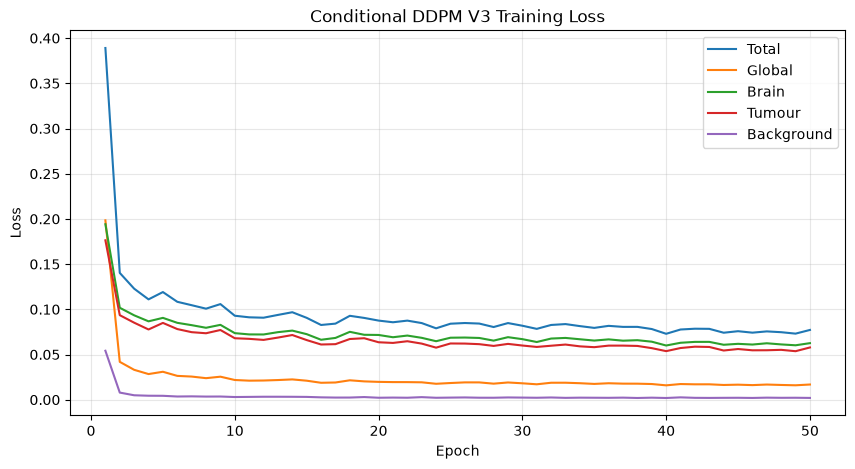

Loaded V3 epoch: 50


Subject: BraTS-GLI-00240-000
Entropy: 6.783998489379883


Generated range: -1.0 1.0


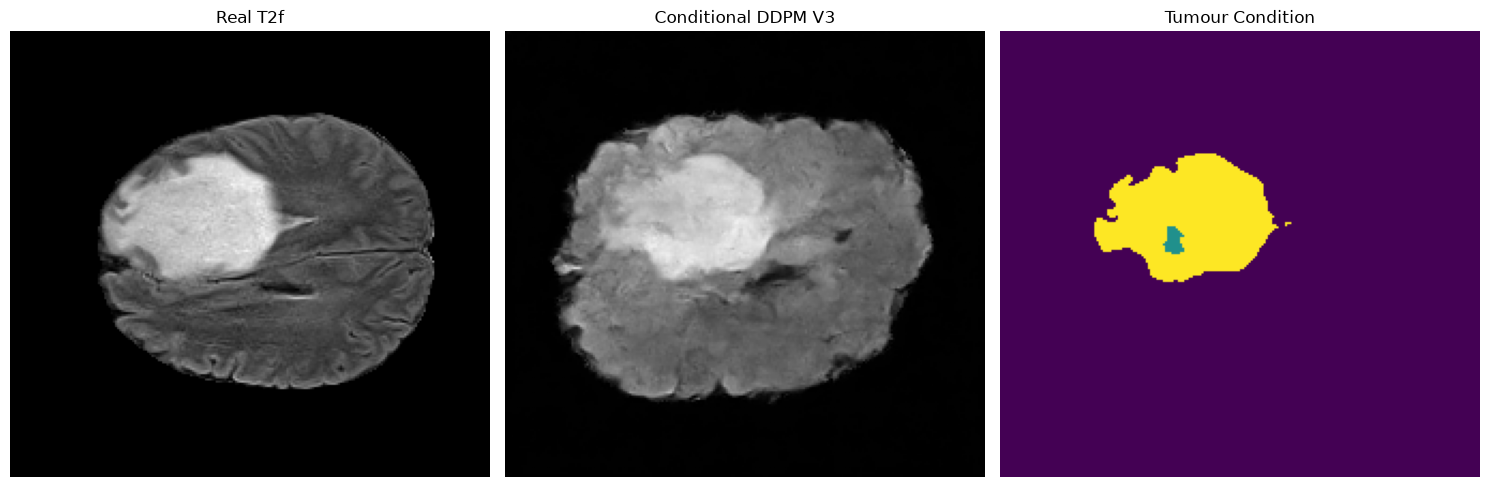

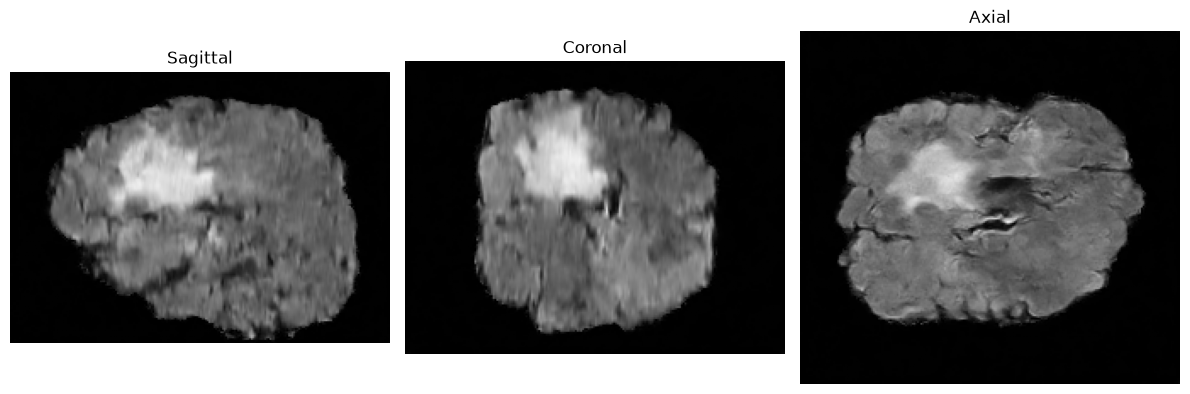

Generated mean: -0.7777696
Generated std: 0.38740063
Generated min: -1.0
Generated max: 1.0


In [25]:
# ============================================================
# Conditional DDPM V3 - Final Results
# ============================================================

loss_history = np.load(
    "conditional_v3_checkpoints/"
    "conditional_v3_loss_history.npy"
)

print(
    "Training epochs:",
    len(loss_history)
)


labels = [
    "Total",
    "Global",
    "Brain",
    "Tumour",
    "Background"
]

plt.figure(
    figsize=(10, 5)
)

for i, label in enumerate(
    labels
):

    plt.plot(
        np.arange(
            1,
            len(loss_history) + 1
        ),
        loss_history[:, i],
        label=label
    )

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

plt.title(
    "Conditional DDPM V3 Training Loss"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.show()


# ------------------------------------------------------------
# Load final checkpoint
# ------------------------------------------------------------

model = ConditionalUNet3D(
    image_channels=1,
    out_channels=1,
    base_channels=16,
    condition_dim=256,
    entropy_scale=0.1
).to(device)

ema = EMA(
    model,
    decay=0.9999
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

loaded_epoch = load_checkpoint(
    model=model,
    ema=ema,
    optimizer=optimizer,
    path=(
        "conditional_v3_checkpoints/"
        "conditional_ddpm_v3_epoch_050.pt"
    ),
    device=device
)

print(
    "Loaded V3 epoch:",
    loaded_epoch
)


# ------------------------------------------------------------
# Condition
# ------------------------------------------------------------

sample = train_dataset[0]

real_image = (
    sample["image"]
    .unsqueeze(0)
    .to(device)
)

mask = (
    sample["mask"]
    .unsqueeze(0)
    .to(device)
)

entropy = (
    sample["heterogeneity"]
    .unsqueeze(0)
    .to(device)
)

print(
    "Subject:",
    sample["subject"]
)

print(
    "Entropy:",
    entropy.item()
)


# ------------------------------------------------------------
# EMA sampling
# ------------------------------------------------------------

torch.manual_seed(
    42
)

generated_v3 = (
    sample_conditional_ddpm(
        model=ema.ema_model,
        shape=(
            1,
            1,
            208,
            224,
            160
        ),
        mask=mask,
        heterogeneity=entropy,
        device=device
    )
)


print(
    "Generated range:",
    generated_v3.min().item(),
    generated_v3.max().item()
)


# ------------------------------------------------------------
# Display preparation
# ------------------------------------------------------------

real_np = (
    real_image[
        0,
        0
    ]
    .detach()
    .cpu()
    .numpy()
)

generated_np = (
    generated_v3[
        0,
        0
    ]
    .detach()
    .cpu()
    .numpy()
)

mask_np = (
    mask[
        0,
        0
    ]
    .detach()
    .cpu()
    .numpy()
)


real_display = np.clip(
    (
        real_np + 1.0
    ) / 2.0,
    0.0,
    1.0
)

generated_display = np.clip(
    (
        generated_np + 1.0
    ) / 2.0,
    0.0,
    1.0
)


tumour_per_slice = (
    mask_np > 0
).sum(
    axis=(0, 1)
)

tumour_slice = int(
    np.argmax(
        tumour_per_slice
    )
)


# ------------------------------------------------------------
# Tumour slice
# ------------------------------------------------------------

plt.figure(
    figsize=(15, 5)
)

plt.subplot(
    1,
    3,
    1
)

plt.imshow(
    real_display[
        :,
        :,
        tumour_slice
    ],
    cmap="gray",
    vmin=0,
    vmax=1
)

plt.title(
    "Real T2f"
)

plt.axis(
    "off"
)


plt.subplot(
    1,
    3,
    2
)

plt.imshow(
    generated_display[
        :,
        :,
        tumour_slice
    ],
    cmap="gray",
    vmin=0,
    vmax=1
)

plt.title(
    "Conditional DDPM V3"
)

plt.axis(
    "off"
)


plt.subplot(
    1,
    3,
    3
)

plt.imshow(
    mask_np[
        :,
        :,
        tumour_slice
    ],
    cmap="viridis"
)

plt.title(
    "Tumour Condition"
)

plt.axis(
    "off"
)

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# Orthogonal views
# ------------------------------------------------------------

x_mid = (
    generated_display.shape[0]
    // 2
)

y_mid = (
    generated_display.shape[1]
    // 2
)

z_mid = (
    generated_display.shape[2]
    // 2
)


plt.figure(
    figsize=(12, 4)
)


plt.subplot(
    1,
    3,
    1
)

plt.imshow(
    generated_display[
        x_mid,
        :,
        :
    ].T,
    cmap="gray",
    origin="lower",
    vmin=0,
    vmax=1
)

plt.title(
    "Sagittal"
)

plt.axis(
    "off"
)


plt.subplot(
    1,
    3,
    2
)

plt.imshow(
    generated_display[
        :,
        y_mid,
        :
    ].T,
    cmap="gray",
    origin="lower",
    vmin=0,
    vmax=1
)

plt.title(
    "Coronal"
)

plt.axis(
    "off"
)


plt.subplot(
    1,
    3,
    3
)

plt.imshow(
    generated_display[
        :,
        :,
        z_mid
    ],
    cmap="gray",
    vmin=0,
    vmax=1
)

plt.title(
    "Axial"
)

plt.axis(
    "off"
)

plt.tight_layout()

plt.show()


print(
    "Generated mean:",
    generated_np.mean()
)

print(
    "Generated std:",
    generated_np.std()
)

print(
    "Generated min:",
    generated_np.min()
)

print(
    "Generated max:",
    generated_np.max()
)